# Exploratory Data Analysis and Visualization – Titanic Dataset

## YuvaIntern Internship – Week 2

**Project:** Exploratory Data Analysis and Visualization  
**Dataset:** Titanic Dataset  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Environment:** Jupyter Notebook

---

## Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) and visualization on the Titanic dataset.

In this analysis, we will:

- Understand the structure of the dataset
- Inspect data types and statistical properties
- Identify missing values
- Check duplicate records
- Handle missing values appropriately
- Analyze numerical and categorical variables
- Identify relationships and correlations
- Detect potential outliers
- Create meaningful visualizations
- Interpret important patterns and trends
- Summarize the major findings from the dataset

# 1. Import Required Libraries

The following Python libraries are used for data analysis and visualization.

- **Pandas** – data loading, manipulation and analysis
- **Matplotlib** – creating charts and plots
- **Seaborn** – statistical visualization and attractive plots
- **NumPy** – numerical operations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Set Seaborn theme
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Load the Dataset

The Titanic dataset is a well-known public dataset containing information about passengers aboard the Titanic.

The dataset contains demographic, travel and survival-related information.

For this project, the dataset is loaded from a local CSV file so that the notebook does not depend on an internet connection while running.

In [3]:
df = sns.load_dataset('titanic')

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Initial Dataset Preview

The `head()` function displays the first five rows of the dataset.
This helps us understand the variables and structure of the data.

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Dataset Shape

The `shape` attribute returns the number of rows and columns
present in the dataset.

In [5]:
df.shape

(891, 15)

## 3.2 Column Names

The `columns` attribute displays the names of all variables present in the dataset.

Examining the column names helps us understand what information is available for analysis.

In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

## 3.3 Dataset Information

The `info()` function provides information about the dataset, including column names, data types, non-null values, and memory usage.

This is useful for understanding the structure and data quality of the dataset.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


# 4. Statistical Summary

The `describe()` function provides descriptive statistics for numerical variables.

It includes count, mean, standard deviation, minimum, quartiles, and maximum values.

These statistics help us understand the central tendency, spread, and range of numerical variables.

In [8]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 5. Missing Value Analysis

Missing values are observations where information is not available.

Identifying missing values is important because they can affect statistical analysis and visualization.

We calculate the number of missing values in each column.

In [9]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
class           0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
dtype: float64

## 5.1 Missing Value Visualization

A bar chart is used to visualize the number of missing values in each column.

This makes it easier to identify which variables contain missing information.

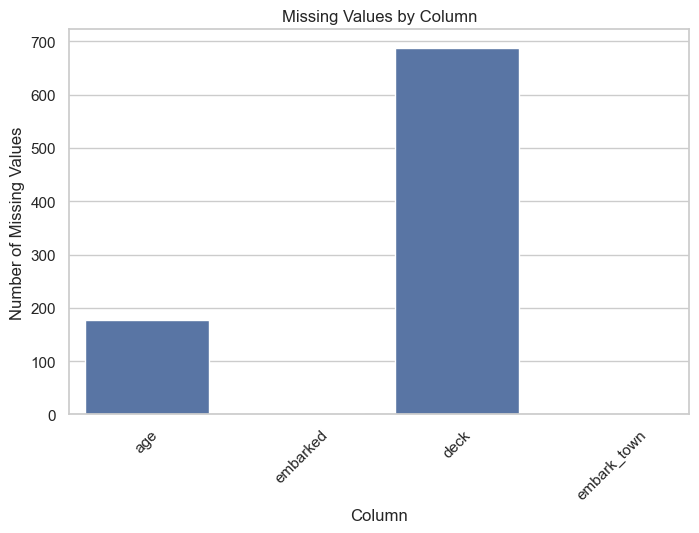

In [11]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(8, 5))

sns.barplot(
    x=missing_values.index,
    y=missing_values.values
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

# 6. Duplicate Value Analysis

Duplicate rows contain repeated records.

We check for duplicate rows because unnecessary duplicates can affect analysis and lead to misleading conclusions.

In [14]:
df.duplicated().sum()

np.int64(107)

# 7. Handling Missing Values

After identifying the missing values, we need to decide how they should be handled.

Different techniques can be used depending on the type and importance of the variable.

For this dataset:

- Missing `age` values will be replaced using the median age.
- Missing `embarked` values will be replaced using the most frequent value (mode).
- `deck` contains a large number of missing values, so it will be excluded from the cleaned dataset.

A separate `df_clean` DataFrame is created so that the original dataset remains unchanged.


In [15]:
df_clean = df.copy()

# Fill missing age values with median
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Fill missing embarked values with mode
df_clean['embarked'] = df_clean['embarked'].fillna(
    df_clean['embarked'].mode()[0]
)

# Remove deck because it contains a large amount of missing data
df_clean = df_clean.drop(columns=['deck'])

## 8.1 Validation After Missing Value Handling

After handling the missing values, we check the dataset again.

This validation step confirms whether the selected missing-value treatment was successfully applied.

In [16]:
df_clean.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [17]:
print("Total remaining missing values:",
      df_clean.isnull().sum().sum())

Total remaining missing values: 2


# 9. Duplicate Handling

Duplicate rows can affect the reliability of an analysis.

We check the cleaned dataset for duplicate records and remove them if necessary.

In [18]:
duplicate_count = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 116


In [19]:
df_clean = df_clean.drop_duplicates()

print("Dataset shape after duplicate removal:", df_clean.shape)

Dataset shape after duplicate removal: (775, 14)


# 10. Cleaned Dataset Overview

After handling missing values and duplicate records, we inspect the cleaned dataset.

This ensures that the dataset is ready for further exploratory analysis and visualization.

In [20]:
df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   sex          775 non-null    object  
 3   age          775 non-null    float64 
 4   sibsp        775 non-null    int64   
 5   parch        775 non-null    int64   
 6   fare         775 non-null    float64 
 7   embarked     775 non-null    object  
 8   class        775 non-null    category
 9   who          775 non-null    object  
 10  adult_male   775 non-null    bool    
 11  embark_town  773 non-null    object  
 12  alive        775 non-null    object  
 13  alone        775 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 75.1+ KB


# 11. Survival Distribution

The `survived` variable represents the survival status of passengers:

- `0` = Did not survive
- `1` = Survived

We first examine the overall distribution of survival outcomes.

In [22]:
df_clean['survived'].value_counts()

survived
0    455
1    320
Name: count, dtype: int64

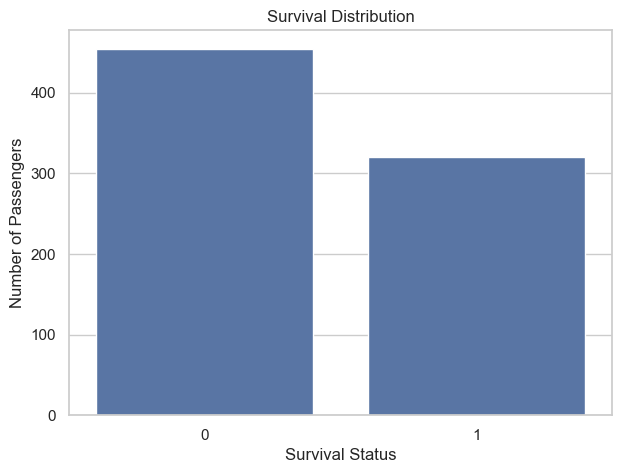

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x='survived')

plt.title('Survival Distribution')
plt.xlabel('Survival Status')
plt.ylabel('Number of Passengers')

plt.show()

### Observation

The count plot compares the number of passengers who survived with those who did not survive.

The visualization shows that the number of non-survivors was higher than the number of survivors.

# 12. Survival by Gender

Gender is an important categorical variable in the Titanic dataset.

We compare survival outcomes between male and female passengers to identify differences in survival patterns.

In [25]:
pd.crosstab(df_clean['sex'], df_clean['survived'])

survived,0,1
sex,,
female,76,216
male,379,104


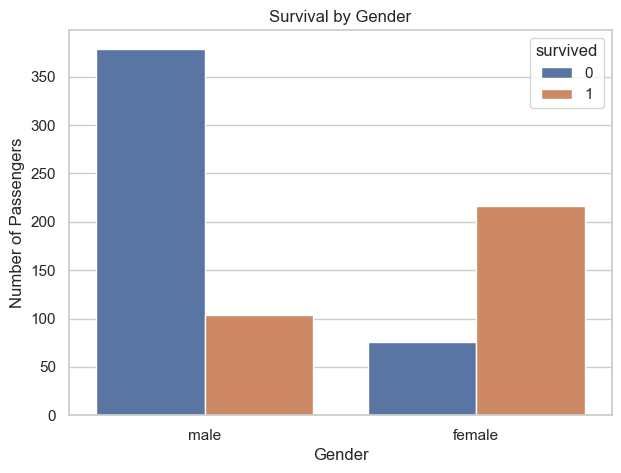

In [26]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_clean,
    x='sex',
    hue='survived'
)

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

### Observation

The visualization shows a clear difference in survival outcomes between male and female passengers.

Female passengers had a noticeably higher number and proportion of survivors compared with male passengers.

# 13. Survival by Passenger Class

The Titanic dataset contains passengers from three passenger classes.

We compare survival outcomes across first, second, and third class to investigate whether passenger class was associated with survival.

In [27]:
pd.crosstab(df_clean['class'], df_clean['survived'])

survived,0,1
class,,
First,77,133
Second,81,83
Third,297,104


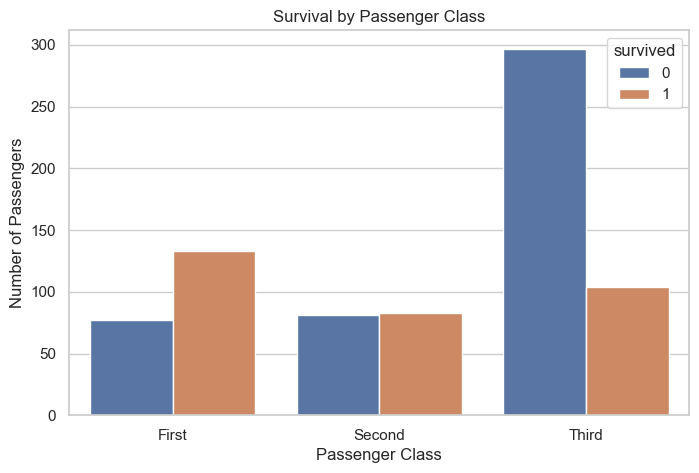

In [28]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x='class',
    hue='survived'
)

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

### Observation

The plot shows different survival patterns across passenger classes.

First-class passengers generally had better survival outcomes, while third-class passengers had a larger number of non-survivors.

# 14. Age Distribution

Age is a numerical variable in the dataset.

A histogram is used to understand the distribution of passenger ages and identify the age ranges in which most passengers were concentrated.

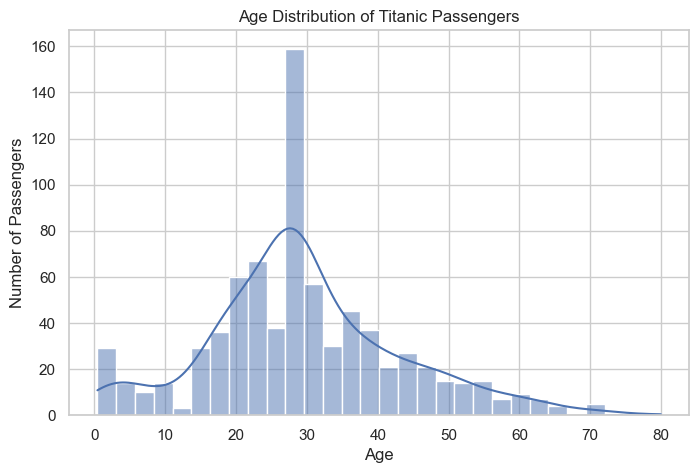

In [30]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x='age',
    bins=30,
    kde=True
)

plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

### Observation

The histogram shows the distribution of passenger ages.

Most passengers were concentrated in the younger and middle-age ranges, while relatively fewer passengers were present at very high ages.

# 15. Fare Distribution

The `fare` variable represents the amount paid by passengers for their tickets.

A histogram is used to understand the distribution of fares and identify whether the variable contains extreme values.

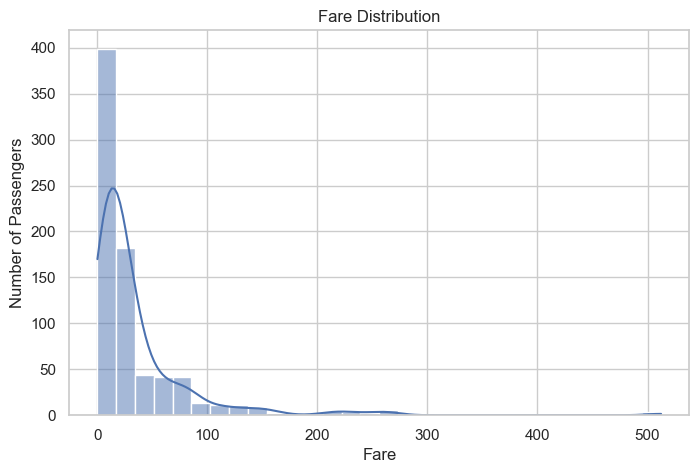

In [31]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x='fare',
    bins=30,
    kde=True
)

plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')

plt.show()

### Observation

The fare distribution is strongly right-skewed.

Most passengers paid relatively lower fares, while a smaller number of passengers paid considerably higher fares.

# 16. Fare by Passenger Class

Passenger class and ticket fare are expected to be related because different classes generally had different ticket prices.

A box plot is used to compare fare distributions across passenger classes.

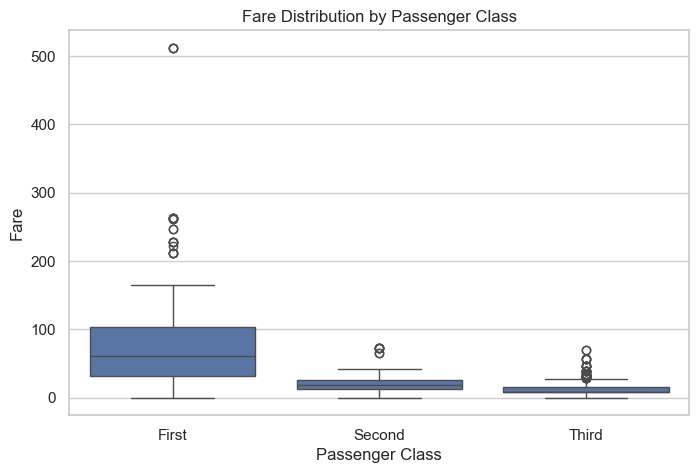

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='class',
    y='fare'
)

plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')

plt.show()

### Observation

The box plot shows that passengers in higher classes generally paid higher fares.

The fare distributions also contain some unusually high values, which may represent potential outliers.

# 17. Age Distribution by Survival

We compare the age distributions of passengers who survived and those who did not survive.

A box plot allows us to compare the median age and overall spread of age between the two survival groups.



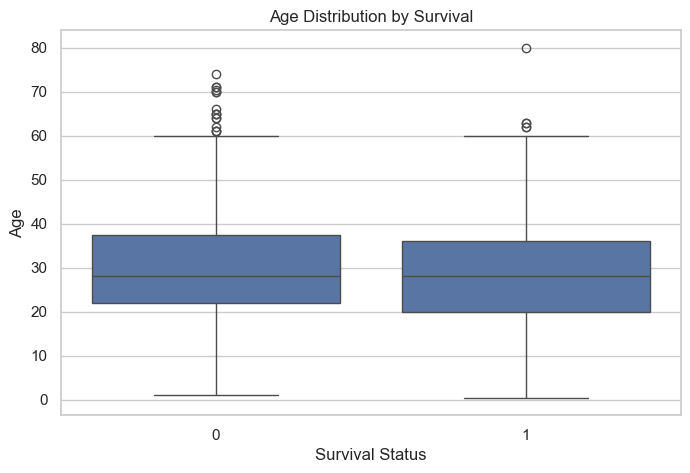

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='survived',
    y='age'
)

plt.title('Age Distribution by Survival')
plt.xlabel('Survival Status')
plt.ylabel('Age')

plt.show()

### Observation

The box plot allows us to compare the age distributions of survivors and non-survivors.

The two groups show some overlap, indicating that age alone does not completely separate passengers based on survival.

# 18. Survival by Port of Embarkation

The `embarked` variable represents the port from which passengers boarded the Titanic.

We compare survival outcomes across the different embarkation ports.

In [34]:
pd.crosstab(df_clean['embarked'], df_clean['survived'])

survived,0,1
embarked,,
C,65,90
Q,38,20
S,352,210


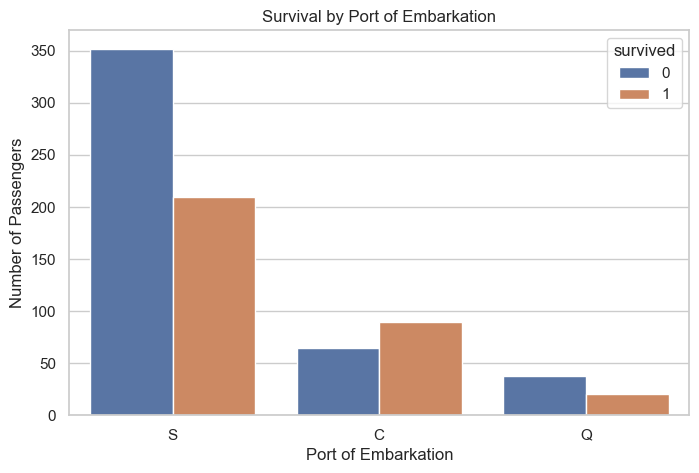

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x='embarked',
    hue='survived'
)

plt.title('Survival by Port of Embarkation')
plt.xlabel('Port of Embarkation')
plt.ylabel('Number of Passengers')

plt.show()

### Observation

The plot shows differences in survival outcomes across the three embarkation ports.

However, these differences should not be interpreted as a direct causal relationship because other passenger characteristics may also influence survival.

# 19. Feature Transformation – Family Size

Feature transformation means creating a new variable from existing variables to obtain additional information.

In the Titanic dataset, `sibsp` represents the number of siblings/spouses aboard and `parch` represents the number of parents/children aboard.

We create a new variable called `family_size`.

Family Size = SibSp + Parch + 1

The value 1 represents the passenger themselves.

This new feature helps us investigate whether travelling with family members was associated with survival.

In [36]:
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1

df_clean[['sibsp', 'parch', 'family_size']].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


# 20. Family Size Distribution

We examine the distribution of the newly created `family_size` variable.

This helps us understand whether passengers generally travelled alone or with family members.

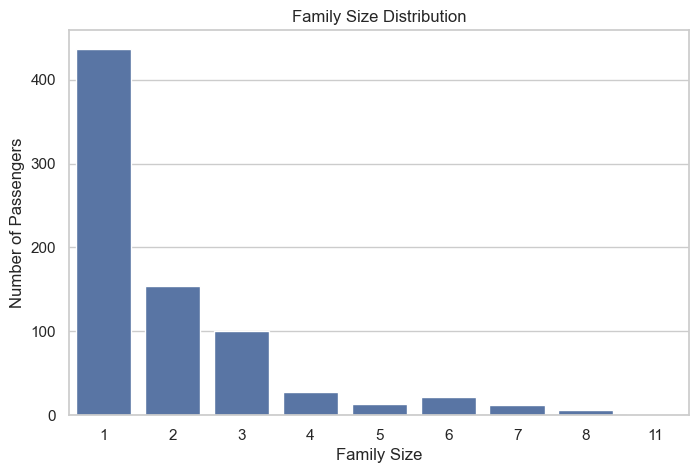

In [37]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x='family_size'
)

plt.title('Family Size Distribution')
plt.xlabel('Family Size')
plt.ylabel('Number of Passengers')

plt.show()

### Observation

The distribution shows how many passengers travelled alone or as part of different family sizes.

Very large family sizes are less common compared with smaller family groups.

# 21. Family Size and Survival

We now investigate whether family size is associated with survival.

The survival rate is calculated for each family size rather than only comparing the number of survivors.

In [38]:
family_survival = (
    df_clean.groupby('family_size')['survived']
    .mean()
    .mul(100)
)

family_survival

family_size
1     33.638444
2     55.194805
3     57.425743
4     71.428571
5     23.076923
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: survived, dtype: float64

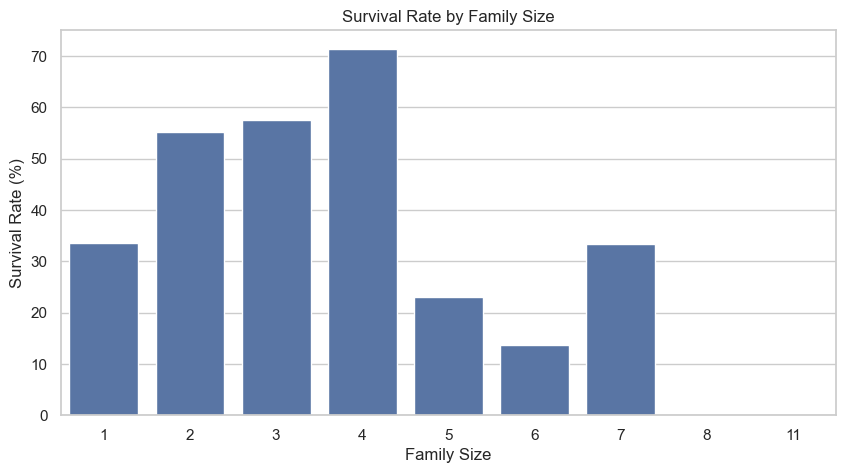

In [39]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=family_survival.index,
    y=family_survival.values
)

plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate (%)')

plt.show()

### Observation

The survival rate varies across different family sizes.

Very small and very large family groups may show different survival patterns. However, family size alone cannot be considered the only factor affecting survival.

# 22. Correlation Analysis

Correlation measures the strength and direction of a linear relationship between numerical variables.

The correlation coefficient generally ranges from -1 to +1.

- A positive value indicates a positive relationship.
- A negative value indicates a negative relationship.
- A value close to zero indicates a weak linear relationship.

Correlation shows association between variables and does not necessarily imply causation.

In [40]:
numeric_df = df_clean.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

correlation_matrix

,survived,pclass,age,sibsp,parch,fare,family_size
survived,1.000000,-0.331388,-0.078114,-0.037841,0.069864,0.247159,0.013954
pclass,-0.331388,1.000000,-0.342745,0.087050,0.038998,-0.554649,0.078134
age,-0.078114,-0.342745,1.000000,-0.279316,-0.182697,0.092503,-0.282479
sibsp,-0.037841,0.087050,-0.279316,1.000000,0.379535,0.133807,0.859784
parch,0.069864,0.038998,-0.182697,0.379535,1.000000,0.190823,0.798767
fare,0.247159,-0.554649,0.092503,0.133807,0.190823,1.000000,0.192341
family_size,0.013954,0.078134,-0.282479,0.859784,0.798767,0.192341,1.000000


## 23.1 Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix.

The values inside the heatmap show the correlation coefficient between numerical variables.

This makes it easier to identify relatively strong positive or negative relationships.

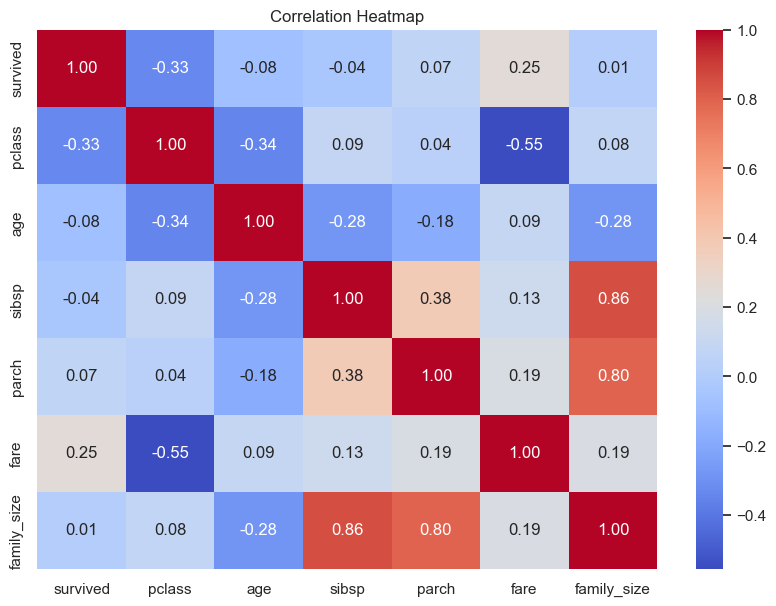

In [41]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Observation

The heatmap provides an overall view of the relationships among numerical variables.

Some variables show stronger associations than others. In particular, passenger class and fare show a noticeable relationship, while several other variables have weaker linear relationships.

# 24. Outlier Analysis

An outlier is an observation that is unusually far from the majority of observations.

Outliers can influence statistical measures such as the mean and standard deviation.

Box plots are used to visually identify potential outliers in numerical variables.

We will examine `age` and `fare`.

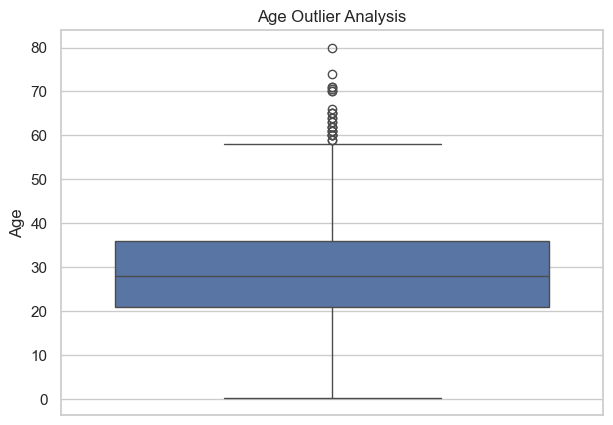

In [42]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    y='age'
)

plt.title('Age Outlier Analysis')
plt.ylabel('Age')

plt.show()

### Observation

The box plot shows the spread of passenger ages and highlights observations that may lie outside the typical range.

Potential outliers should not automatically be removed because they may represent genuine observations.

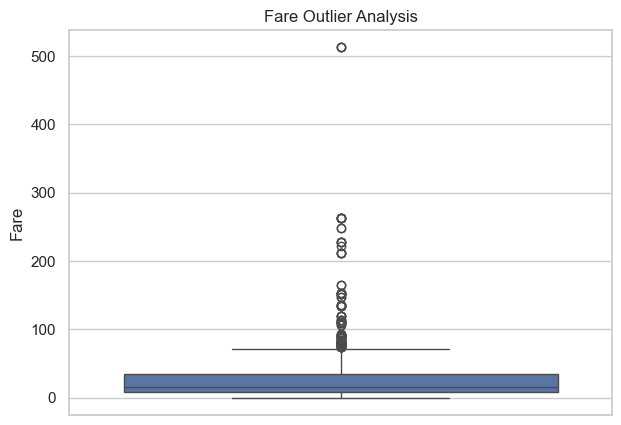

In [43]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_clean,
    y='fare'
)

plt.title('Fare Outlier Analysis')
plt.ylabel('Fare')

plt.show()

### Observation

The fare variable contains several potential high-value outliers.

These values may represent passengers who paid considerably higher fares and should not automatically be removed without understanding their context.

## 27.1 IQR-Based Outlier Detection

The Interquartile Range (IQR) provides a statistical method for identifying potential outliers.

IQR = Q3 − Q1

Potential outlier boundaries are calculated as:

Lower Bound = Q1 − 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

In [44]:
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 8.05
Q3: 34.197900000000004
IQR: 26.147900000000003
Lower Bound: -31.171850000000003
Upper Bound: 73.41975000000001


In [45]:
fare_outliers = df_clean[
    (df_clean['fare'] < lower_bound) |
    (df_clean['fare'] > upper_bound)
]

print("Number of potential fare outliers:", len(fare_outliers))

Number of potential fare outliers: 102


# 28. Final Data Quality Check

After completing the cleaning, transformation, and exploratory analysis, we perform a final validation of the working dataset.

We check:

- Dataset dimensions
- Remaining missing values
- Duplicate records
- Data types
- Newly created features

In [46]:
print("Final dataset shape:", df_clean.shape)
print("Total missing values:", df_clean.isnull().sum().sum())
print("Total duplicate rows:", df_clean.duplicated().sum())

Final dataset shape: (775, 15)
Total missing values: 2
Total duplicate rows: 0


In [47]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   sex          775 non-null    object  
 3   age          775 non-null    float64 
 4   sibsp        775 non-null    int64   
 5   parch        775 non-null    int64   
 6   fare         775 non-null    float64 
 7   embarked     775 non-null    object  
 8   class        775 non-null    category
 9   who          775 non-null    object  
 10  adult_male   775 non-null    bool    
 11  embark_town  773 non-null    object  
 12  alive        775 non-null    object  
 13  alone        775 non-null    bool    
 14  family_size  775 non-null    int64   
dtypes: bool(2), category(1), float64(2), int64(5), object(5)
memory usage: 81.1+ KB


# 29. Key Findings

The exploratory analysis of the Titanic dataset produced several important findings:

1. The dataset contains both numerical and categorical variables.

2. Missing values were identified in several columns and were handled using appropriate techniques.

3. The overall number of passengers who did not survive was higher than the number of passengers who survived.

4. Survival outcomes differed considerably between male and female passengers.

5. Passenger class showed noticeable differences in survival outcomes, with first-class passengers generally having better survival outcomes.

6. Passenger fares were strongly right-skewed, with several potential high-value outliers.

7. Passenger class and fare showed a noticeable relationship.

8. The newly created `family_size` feature allowed us to investigate the relationship between family travelling patterns and survival.

9. The correlation heatmap provided an overview of relationships between numerical variables.

10. Box plots and IQR analysis helped identify potential outliers in numerical variables.

# 30. Conclusion

Exploratory Data Analysis was performed on the Titanic dataset using Python, Pandas, Matplotlib, and Seaborn.

The analysis began with understanding the structure, size, columns, data types, and statistical characteristics of the dataset. Missing values and duplicate records were then identified and handled using appropriate data-cleaning techniques.

Several visualizations were created to understand passenger survival, gender, passenger class, age, fare, embarkation port, and family size. Relationship analysis and correlation analysis were also performed to identify associations between numerical variables.

A new `family_size` feature was created from existing variables to provide an additional perspective on passenger travel patterns. Outlier analysis was performed using box plots and the Interquartile Range method.

Overall, the EDA process helped transform the raw dataset into meaningful information and provided a better understanding of the patterns, relationships, distributions, and anomalies present in the Titanic dataset.

# 31. Project Summary

## Dataset
Titanic Dataset

## Programming Language
Python

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn

## Analysis Performed
- Initial data exploration
- Statistical analysis
- Missing value analysis
- Missing value treatment
- Duplicate analysis
- Categorical analysis
- Numerical analysis
- Feature transformation
- Survival analysis
- Relationship analysis
- Correlation analysis
- Outlier detection

## Visualizations Created
- Survival distribution
- Survival by gender
- Survival by passenger class
- Age distribution
- Fare distribution
- Fare by passenger class
- Age by survival
- Survival by embarkation port
- Family size distribution
- Family size vs survival
- Correlation heatmap
- Age boxplot
- Fare boxplot

## Final Outcome

The project demonstrates how Exploratory Data Analysis can be used to inspect, clean, visualize, and interpret a real-world dataset before applying further statistical or machine-learning techniques.

# 32. Final Project Validation

Before submitting the project, the final dataset and analysis are validated to ensure that the required EDA steps have been completed successfully.

In [49]:
print("Final Dataset Shape:", df_clean.shape)
print("Total Missing Values:", df_clean.isnull().sum().sum())
print("Total Duplicate Rows:", df_clean.duplicated().sum())

Final Dataset Shape: (775, 15)
Total Missing Values: 2
Total Duplicate Rows: 0


In [50]:
df_clean.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1


# 33. Overall Conclusion

This project successfully performed Exploratory Data Analysis and Visualization on the Titanic dataset.

The analysis included initial dataset exploration, descriptive statistics, missing-value analysis, data cleaning, duplicate checking, categorical and numerical analysis, feature transformation, visualization, correlation analysis, and outlier detection.

Multiple visualizations were used to identify important patterns and relationships within the dataset. The analysis also demonstrated how data-cleaning and feature-transformation techniques can improve the quality and usefulness of a dataset for further analysis.

The results obtained from this EDA provide a clear understanding of the major characteristics and patterns present in the Titanic dataset and provide a foundation for further machine-learning analysis.